In [15]:
import geopandas as gpd
import pandas as pd

In [22]:
gdf = gpd.read_file("/Users/szelie/data/unu/agroforestry_systems/dominican_republic.geojson")


In [193]:
gdf

,uid,key_species,associated_species,canopy_height,forest_cover,land_use,land_use_class,has_associates,system_type,geometry,shade_potential,refined_shade_potential,species_shade_score,value,impf_tc,impact_func_id,impf_TC,n_species,has_species
0,28,Coffea arabica,,17.0,88.0,10.0,Tree cover,False,Likely agroforestry,POINT (-70.62000 18.98000),0.823333,NaN,NaN,0.823333,1,2,2,0,False
1,81,Theobroma cacao,,6.0,0.0,10.0,Tree cover,False,Mixed or unclear,POINT (-71.22754 19.60170),0.100000,NaN,NaN,0.100000,3,3,3,0,False
2,247,Coffea arabica,Plantago major,10.0,70.0,30.0,Grassland,True,Mixed or unclear,POINT (-69.65000 18.52000),0.516667,NaN,NaN,0.516667,2,2,2,1,True
3,322,Coffea arabica,"Annona haitiensis, Portulaca grandiflora, Tect...",NaN,NaN,50.0,Built-up,True,Unknown,POINT (-69.94000 18.48000),0.000000,NaN,NaN,0.000000,3,0,0,3,True
4,500,Coffea arabica,,12.0,29.0,30.0,Grassland,False,Mixed or unclear,POINT (-71.44000 18.60000),0.345000,NaN,NaN,0.345000,3,2,2,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,584677,Theobroma cacao,"Cyclopeltis semicordata, Guarea guidonia, Pipe...",25.0,92.0,10.0,Tree cover,True,Likely agroforestry,POINT (-69.46615 19.06785),0.976667,0.838333,0.800000,0.976667,1,1,1,5,True
132,584796,Musa acuminata,"Alpinia purpurata, Bixa orellana, Bursera sima...",8.0,21.0,10.0,Tree cover,True,Mixed or unclear,POINT (-70.41442 19.75092),0.238333,0.402500,0.566667,0.238333,3,3,3,17,True
133,584990,Theobroma cacao,,14.0,35.0,30.0,Grassland,False,Mixed or unclear,POINT (-69.48076 18.67022),0.408333,NaN,NaN,0.408333,3,2,2,0,False
134,585046,Coffea arabica,,28.0,97.0,10.0,Tree cover,False,Likely agroforestry,POINT (-71.29601 18.11522),1.000000,NaN,NaN,1.000000,1,1,1,0,False


## Let's estimate shade potential = the exposure
To estimate the ability of each system to provide shade—an important ecosystem service in agroforestry systems—we define a shade potential index ranging from 0 (no shade) to 1 (maximum shade). This index combines structural and land cover attributes as follows:

Canopy height: taller trees typically provide more shade. Canopy height is normalised assuming a maximum of 30 meters.
Forest cover: derived from remote sensing, this is normalised assuming a maximum of 100%.
The average of these two scores forms the base shade potential.
Additionally, we apply a small adjustment based on the inferred system type:

If the system is classified as Likely agroforestry, we add a bonus of +0.1.
If the system type is Unknown, we subtract 0.1 to reflect greater uncertainty.
The final value is constrained to remain within the [0, 1] range.

This index can be used as a proxy for shade-dependent benefits such as microclimate regulation, soil moisture retention, and resilience to temperature extremes.

In [24]:
def compute_shade(row):
    if pd.isna(row["canopy_height"]) and pd.isna(row["forest_cover"]):
        return 0

    # Normalize canopy height (assuming max 30m)
    h_score = min(row["canopy_height"] / 30, 1) if pd.notna(row["canopy_height"]) else 0

    # Normalize forest cover (assuming max 100%)
    f_score = min(row["forest_cover"] / 100, 1) if pd.notna(row["forest_cover"]) else 0

    # Average both
    base_score = (h_score + f_score) / 2

    # Bonus or penalty based on system type
    if row["system_type"] == "Likely agroforestry":
        base_score += 0.1
    elif row["system_type"] == "Unknown":
        base_score -= 0.1

    return min(max(base_score, 0), 1)

gdf["shade_potential"] = gdf.apply(compute_shade, axis=1)

In [43]:
import pandas as pd
import numpy as np

# Load the shade score table
shade_scores_df = pd.read_csv("/Users/szelie/Downloads/Shade_Scores_for_Associated_Species.csv")

# Clean and lowercase species names for matching
shade_dict = {
    k.strip().lower(): v
    for k, v in zip(shade_scores_df["associated_species"], shade_scores_df["shade_score"])
}

# Helper function to parse species from a stringified set
def safe_parse_species(val):
    if isinstance(val, str) and val.strip():
        return [s.strip().lower() for s in val.strip("{} ").split(",")]
    return []

# Compute shade score based only on associated species
def compute_species_shade(val):
    species_list = safe_parse_species(val)
    species_scores = [shade_dict[s] for s in species_list if s in shade_dict]
    return np.nanmean(species_scores) if species_scores else np.nan

# Apply to get species-only score
gdf["species_shade_score"] = gdf["associated_species"].apply(compute_species_shade)

# Compute refined score that includes canopy height and forest cover
def compute_refined_shade(row):
    if pd.isna(row["canopy_height"]) and pd.isna(row["forest_cover"]):
        return np.nan

    # Normalized scores
    h_score = min(row["canopy_height"] / 30, 1) if pd.notna(row["canopy_height"]) else 0
    f_score = min(row["forest_cover"] / 100, 1) if pd.notna(row["forest_cover"]) else 0
    base_score = (h_score + f_score) / 2

    species_score = row["species_shade_score"]
    if pd.isna(species_score):
        return np.nan

    total_score = (base_score + species_score) / 2
    return min(max(total_score, 0), 1)

# Apply to compute final shade potential
gdf["refined_shade_potential"] = gdf.apply(compute_refined_shade, axis=1)

# Count non-NaN results
print("✅ Points with species shade score:", gdf["species_shade_score"].notna().sum())
print("✅ Points with refined shade potential:", gdf["refined_shade_potential"].notna().sum())


✅ Points with species shade score: 63
✅ Points with refined shade potential: 61


/var/folders/f5/lms0b90j1kx7kk4v552qkjqw0000gp/T/ipykernel_74677/2903882610.py:23: RuntimeWarning: Mean of empty slice
  return np.nanmean(species_scores) if species_scores else np.nan


In [45]:
import matplotlib.pyplot as plt

In [49]:
from climada.entity import Exposures

<Axes: >

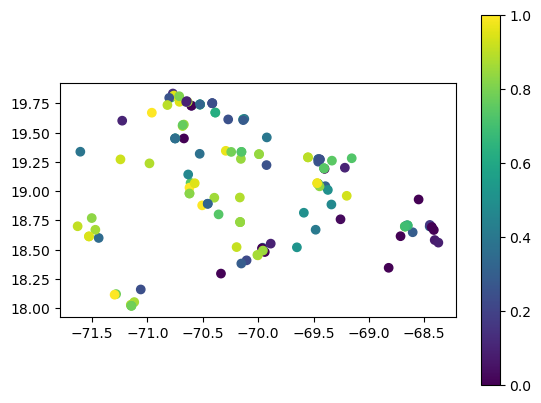

In [95]:
exposures = Exposures(gdf)
exposures.gdf.value = exposures.gdf.shade_potential*100
exposures.gdf.plot('shade_potential', legend='True')

In [67]:
from climada.util.api_client import Client
tc_hist = client.get_hazard('tropical_cyclone', properties={"country_iso3alpha":"DOM", "event_type":"observed"})

In [83]:
def assign_if_id_from_shade(score):
    if pd.isna(score):
        return 0  # Default or unknown
    elif score > 0.75:
        return 1  # High vulnerability
    elif score > 0.5:
        return 2  # Medium vulnerability
    else:
        return 3  # Low vulnerability

# Apply to your GeoDataFrame
exposures.gdf["impf_TC"] = gdf["shade_potential"].apply(assign_if_id_from_shade)


2025-05-28 11:20:52,086 - climada.entity.impact_funcs.impact_func_set - WARNING - Input ImpactFunc's id not set.


array([[<Axes: title={'center': 'TC 1: High vulnerability (dense, tall canopy)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'TC 2: Medium vulnerability (moderate canopy)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'TC 3: Low vulnerability (sparse or short canopy)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'TC 0: Unknown / default'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>]],
      dtype=object)

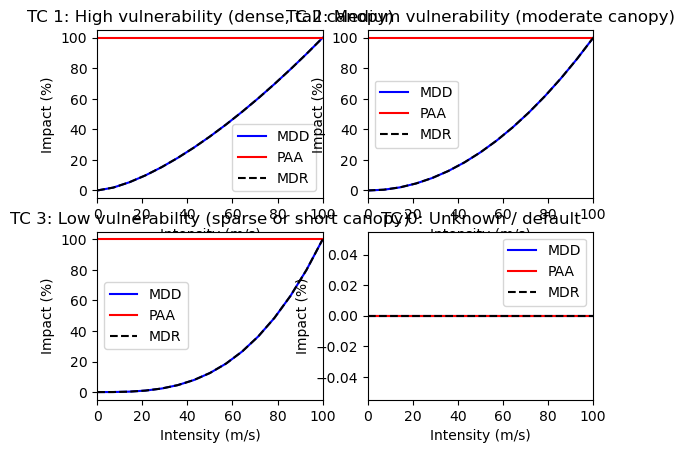

In [73]:
from climada.entity import ImpactFunc, ImpactFuncSet
import numpy as np

# Initialize the Impact Function Set
impf_set = ImpactFuncSet()

# Define impact functions for different vulnerability levels
def make_impact_func(if_id, name, intensity, mdd, paa):
    impf = ImpactFunc()
    impf.haz_type = 'TC'
    impf.id = if_id
    impf.name = name
    impf.intensity_unit = 'm/s'
    impf.intensity = intensity
    impf.mdd = mdd
    impf.paa = paa
    impf.check()
    return impf

# Define the shared intensity scale (wind speed in m/s)
intensity = np.linspace(0, 100, 15)

# Example damage curves (you can replace these with empirical values)
impf_set.append(make_impact_func(
    1, 'High vulnerability (dense, tall canopy)',
    intensity,
    mdd=np.linspace(0, 1, 15)**1.5,
    paa=np.ones(15)
))

impf_set.append(make_impact_func(
    2, 'Medium vulnerability (moderate canopy)',
    intensity,
    mdd=np.linspace(0, 1, 15)**2,
    paa=np.ones(15)
))

impf_set.append(make_impact_func(
    3, 'Low vulnerability (sparse or short canopy)',
    intensity,
    mdd=np.linspace(0, 1, 15)**3,
    paa=np.ones(15)
))

# Optional: fallback
impf_set.append(make_impact_func(
    0, 'Unknown / default',
    intensity,
    mdd=np.zeros(15),
    paa=np.zeros(15)
))

impf_set.plot()

In [96]:
def assign_impact_func_id(height):
    if pd.isna(height):
        return 0
    elif height >= 20:
        return 1  # high vulnerability
    elif height >= 10:
        return 2  # medium
    else:
        return 3  # low

gdf['impf_TC'] = gdf['canopy_height'].apply(assign_impact_func_id)


In [168]:
exposures.value

array([ 82.33333333,  10.        ,  51.66666667,   0.        ,
        34.5       ,  99.66666667,   2.5       ,  39.66666667,
        49.83333333,  47.16666667,   0.        ,  85.83333333,
         0.        ,  91.        ,  30.5       ,  73.5       ,
        91.16666667,  32.33333333,  24.        ,  15.5       ,
       100.        ,  96.66666667,  73.        ,  82.83333333,
        25.33333333,  82.33333333,  39.        ,  86.5       ,
        32.33333333,   0.        ,  73.        ,  77.83333333,
        94.33333333,   0.5       ,  36.33333333,  13.33333333,
        41.16666667,  32.83333333,   6.66666667,  74.16666667,
         0.        ,   8.33333333,  31.5       ,  76.83333333,
        86.5       ,  23.83333333,   0.        ,  71.5       ,
        68.        ,  54.16666667,  88.33333333,   0.        ,
        49.83333333,  68.5       ,  91.5       ,  88.        ,
        90.33333333,  20.        ,  84.5       ,  68.33333333,
        26.83333333, 100.        ,   0.        ,  84.  

Expected annual impact (EAI): 197.72 USD
Expected annual impact (EAI in %): 2.63%


<Axes: title={'center': 'Exceedance frequency curve (% of exposed value)'}, xlabel='Return period (year)', ylabel='Impact (%)'>

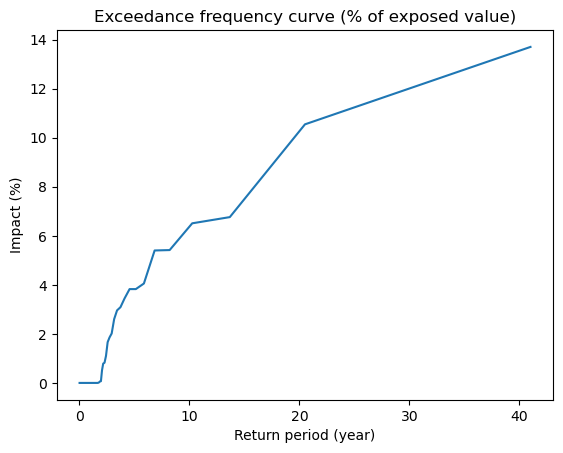

In [171]:
from climada.engine import ImpactCalc, ImpactFreqCurve
from climada.entity import ImpactFuncSet

# 1. Ensure all 3 objects are ready:
# - `haz_wind`: your tropical cyclone hazard
# - `exp_agroforestry`: your exposures object (with `value`, `impact_func_id`)
# - `imp_fun_set`: your ImpactFuncSet (with ids 1, 2, 3 etc.)

# 2. Compute Impact
impact = ImpactCalc(exposures, impf_set, tc_hist).impact(save_mat=True)
# 3. Print expected annual impact
print(f"Expected annual impact (EAI): {impact.aai_agg:.2f} {exposures.value_unit}")
print(f"Expected annual impact (EAI in %): {impact.aai_agg / exposures.gdf['value'].sum():.2%}")



# 5. Normalize to % of exposed value
total_value = exposures.gdf['value'].sum()
impact_pct = 100 * ifc.impact / total_value

# 6. Create percent-based frequency curve
ifc_pct = ImpactFreqCurve(
    return_per=ifc.return_per,
    impact=ifc.impact,
    unit="%",
    frequency_unit=ifc.frequency_unit,
    label="Exceedance frequency curve (% of exposed value)"
)

# 7. Plot percent-based curve
ifc_pct.plot()


<GeoAxes: title={'center': 'Expected annual impact'}>

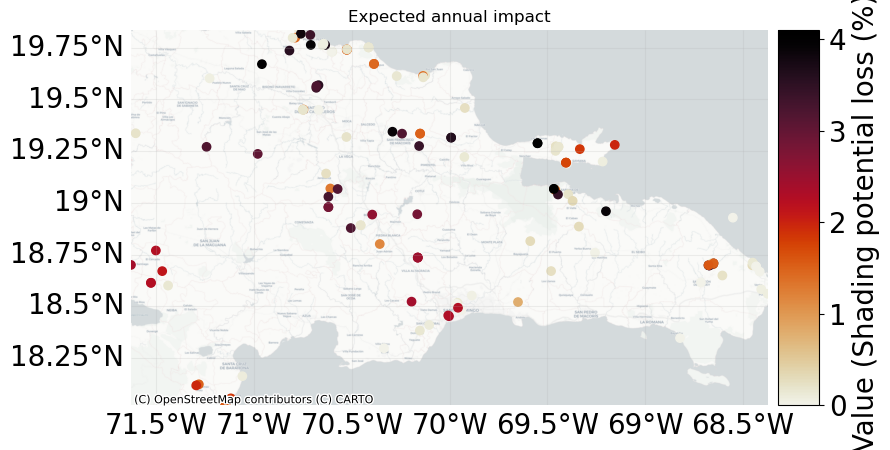

In [98]:
impact.unit = "Shading potential loss (%)"
impact.plot_basemap_eai_exposure(pop_name=False)

In [101]:
from climada.util.api_client import Client
tc_hist_proba = client.get_hazard('tropical_cyclone', properties={"country_iso3alpha":"DOM", "event_type":"synthetic", "climate_scenario":"None"})

In [108]:
from climada.util.api_client import Client
tc_future_proba = client.get_hazard('tropical_cyclone', properties={"country_iso3alpha":"DOM", "event_type":"synthetic", "climate_scenario":"rcp85", 'ref_year': '2060'})

Historic EAI: 223.62 (2.97%)
Future EAI: 246.94 (3.28%)


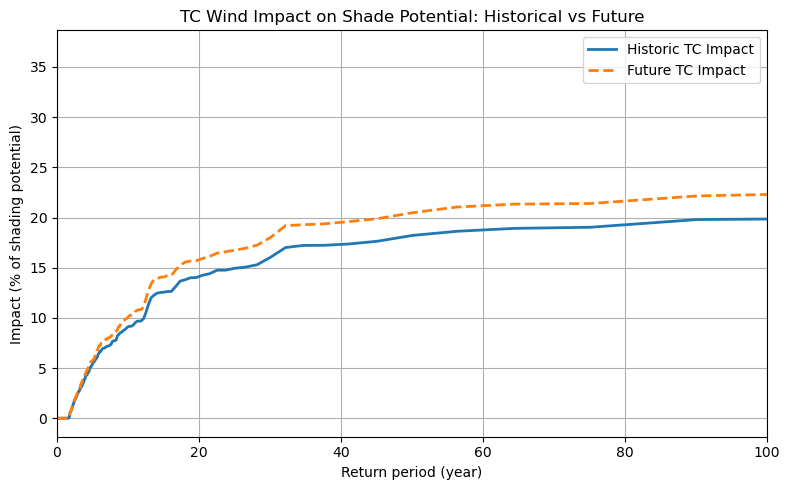

In [159]:
from climada.engine import ImpactCalc, ImpactFreqCurve
import matplotlib.pyplot as plt

# Historical impact
impact_hist = ImpactCalc(exposures, impf_set, tc_hist_proba).impact(save_mat=True)
ifc_hist = impact_hist.calc_freq_curve()
total_val = exposures.gdf.value.sum()
impact_pct_hist = 100 * ifc_hist.impact / total_val

# Future impact
impact_future = ImpactCalc(exposures, impf_set, tc_future_proba).impact(save_mat=True)
ifc_future = impact_future.calc_freq_curve()
impact_pct_future = 100 * ifc_future.impact / total_val

# Print comparison
print(f"Historic EAI: {impact_hist.aai_agg:.2f} ({impact_hist.aai_agg/total_val:.2%})")
print(f"Future EAI: {impact_future.aai_agg:.2f} ({impact_future.aai_agg/total_val:.2%})")

# Plot frequency curve comparison
plt.figure(figsize=(8, 5))
plt.plot(ifc_hist.return_per, impact_pct_hist, label="Historic TC Impact", linewidth=2)
plt.plot(ifc_future.return_per, impact_pct_future, label="Future TC Impact", linewidth=2, linestyle='--')
plt.xlabel("Return period (year)")
plt.ylabel("Impact (% of shading potential)")
plt.title("TC Wind Impact on Shade Potential: Historical vs Future")
plt.xlim(0,100)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [183]:
import copy
from climada.entity import Exposures
from climada.engine import ImpactCalc


# Step 1: Copy the baseline exposures
exp_adapted = copy.deepcopy(exposures)

# Step 2: Trim canopy height to a defined max height (e.g., 10 metres)
exp_adapted.gdf["canopy_height"] = exp_adapted.gdf["canopy_height"].clip(upper=10)

# Step 3: Reassign impact function ID based on the trimmed height
def assign_impact_func(height):
    if height < 6:
        return 1  # low vulnerability
    elif height < 12:
        return 2  # medium vulnerability
    else:
        return 3  # high vulnerability

exp_adapted.gdf["impf_TC"] = exp_adapted.gdf["canopy_height"].apply(assign_impact_func)

# Keep the same units
exp_adapted.value_unit = exposures.value_unit


impact_adapted = ImpactCalc(exp_adapted, impf_set, tc_future_proba).impact(save_mat=False)

# Print results
print(f"Expected annual impact (EAI, adapted): {impact_adapted.aai_agg:.2f} {exp_adapted.value_unit}")
print(f"Relative EAI (adapted): {impact_adapted.aai_agg / exp_adapted.gdf['value'].sum():.2%}")


Expected annual impact (EAI, adapted): 184.14 USD
Relative EAI (adapted): 2.45%


🔴 Baseline system:
  EAI: 246.94 USD
  EAI (%): 3.28%
🟢 Adapted system (trimmed trees):
  EAI: 184.14 USD
  EAI (%): 2.45%


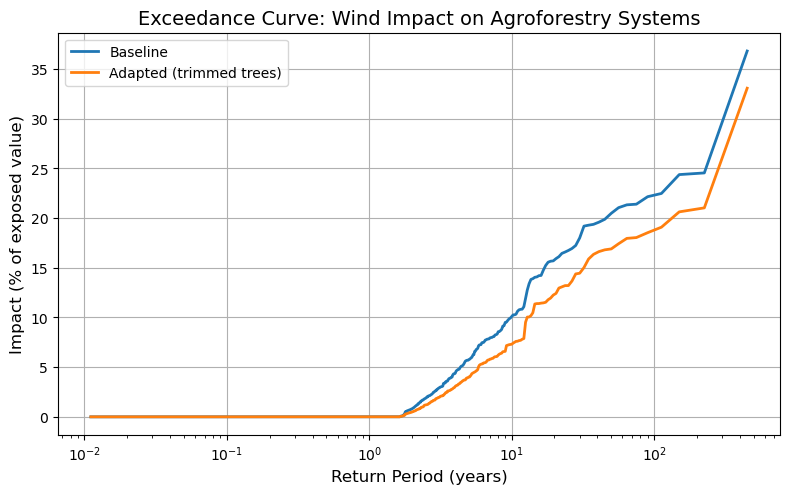

In [185]:
from climada.engine import ImpactCalc, ImpactFreqCurve

# --- 1. Compute impact for baseline (no adaptation) ---
impact_baseline = ImpactCalc(exposures, impf_set, tc_future_proba).impact(save_mat=False)

# --- 2. Compute impact for adapted exposure (trees trimmed) ---
impact_adapted = ImpactCalc(exp_adapted, impf_set, tc_future_proba).impact(save_mat=False)

# --- 3. Print expected annual impact ---
print("🔴 Baseline system:")
print(f"  EAI: {impact_baseline.aai_agg:.2f} {exposures.value_unit}")
print(f"  EAI (%): {impact_baseline.aai_agg / exposures.gdf['value'].sum():.2%}")

print("🟢 Adapted system (trimmed trees):")
print(f"  EAI: {impact_adapted.aai_agg:.2f} {exp_adapted.value_unit}")
print(f"  EAI (%): {impact_adapted.aai_agg / exp_adapted.gdf['value'].sum():.2%}")

# --- 4. Plot both exceedance curves ---
ifc_baseline = impact_baseline.calc_freq_curve()
ifc_adapted = impact_adapted.calc_freq_curve()

import matplotlib.pyplot as plt

# Normalize to percent of total exposed value
val_baseline = exposures.gdf['value'].sum()
val_adapted = exp_adapted.gdf['value'].sum()

plt.figure(figsize=(8, 5))
plt.plot(ifc_baseline.return_per, 100 * ifc_baseline.impact / val_baseline, label='Baseline', lw=2)
plt.plot(ifc_adapted.return_per, 100 * ifc_adapted.impact / val_adapted, label='Adapted (trimmed trees)', lw=2)
plt.xlabel("Return Period (years)", fontsize=12)
plt.ylabel("Impact (% of exposed value)", fontsize=12)
plt.title("Exceedance Curve: Wind Impact on Agroforestry Systems", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xscale("log")
plt.show()


In [179]:
exp_adapted.gdf.impact_func_id

0      2
1      2
2      2
3      3
4      2
      ..
131    2
132    2
133    2
134    2
135    2
Name: impact_func_id, Length: 136, dtype: int64

In [180]:
exposures.gdf.impact_func_id

0      2
1      3
2      2
3      0
4      2
      ..
131    1
132    3
133    2
134    1
135    2
Name: impact_func_id, Length: 136, dtype: int64

array([[<Axes: title={'center': 'TC 1: High vulnerability (dense, tall canopy)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'TC 2: Medium vulnerability (moderate canopy)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>],
       [<Axes: title={'center': 'TC 3: Low vulnerability (sparse or short canopy)'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>,
        <Axes: title={'center': 'TC 0: Unknown / default'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>]],
      dtype=object)

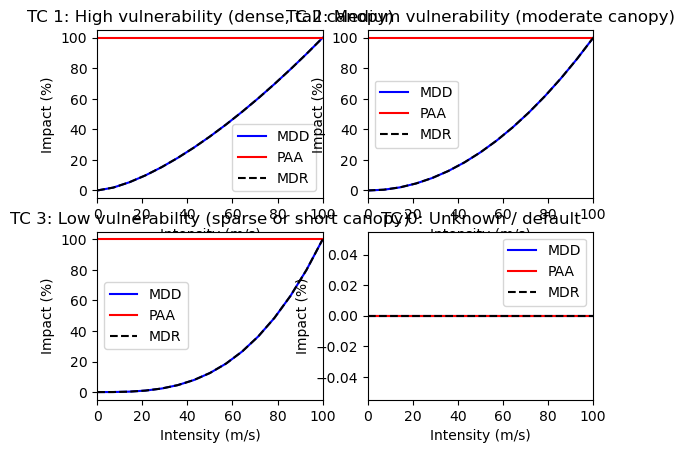

In [182]:
impf_set.plot()

# can we also work with associated tree species?

In [186]:
total_points = len(gdf)
with_species = gdf["associated_species"].apply(lambda x: isinstance(x, str) and len(x.strip("{} ")) > 0).sum()

print(f"{with_species}/{total_points} points ({100 * with_species / total_points:.1f}%) have at least one associated species.")


98/136 points (72.1%) have at least one associated species.


In [187]:
def count_species(val):
    if isinstance(val, str) and val.strip():
        return len(val.strip("{} ").split(","))
    return 0

gdf["n_species"] = gdf["associated_species"].apply(count_species)
print(f"Mean associated species per point: {gdf['n_species'].mean():.2f}")


Mean associated species per point: 9.01


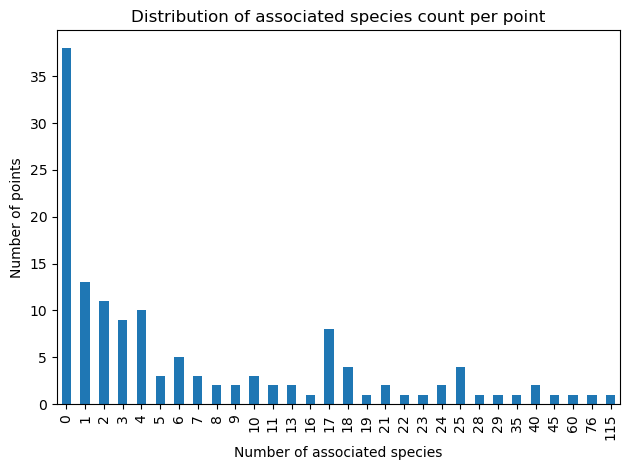

In [188]:
import matplotlib.pyplot as plt

gdf["n_species"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of associated species")
plt.ylabel("Number of points")
plt.title("Distribution of associated species count per point")
plt.tight_layout()
plt.show()


In [189]:
from collections import Counter

all_species = []
for val in gdf["associated_species"]:
    if isinstance(val, str) and val.strip():
        all_species.extend([s.strip().lower() for s in val.strip("{} ").split(",")])

species_freq = Counter(all_species)
species_df = pd.DataFrame(species_freq.items(), columns=["species", "count"]).sort_values("count", ascending=False)
print(species_df.head(10))


                   species  count
11          cocos nucifera     22
19      morinda citrifolia     21
59    roystonea borinquena     18
12     codiaeum variegatum     18
5         mangifera indica     17
9            carica papaya     15
150         hamelia patens     14
146  spathodea campanulata     14
141      alpinia purpurata     14
8            bixa orellana     13


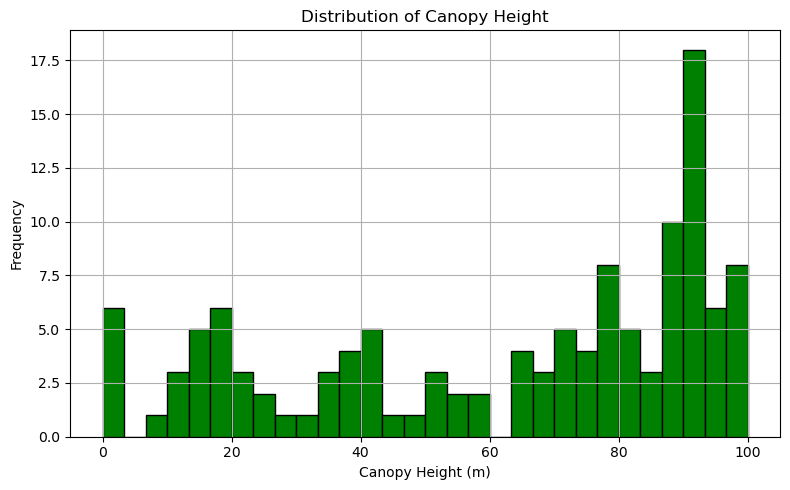

In [195]:
import matplotlib.pyplot as plt

# Filter out NaN values
canopy_data = gdf["forest_cover"].dropna()

# Plot distribution
plt.figure(figsize=(8, 5))
plt.hist(canopy_data, bins=30, color='green', edgecolor='black')
plt.xlabel("Canopy Height (m)")
plt.ylabel("Frequency")
plt.title("Distribution of Canopy Height")
plt.grid(True)
plt.tight_layout()
plt.show()
